# LEFT OVER 

In [ ]:
# df contient : value, position, window_tf, method
methods = df["method"].unique()
# methods = methods[1:]
for method in methods:
    # Filtrer pour la méthode
    df_method = df[df["method"] == method]

    # Créer un dictionnaire clé=(position, window_tf)
    dist_dict = {}
    for (pos, win), group in df_method.groupby(["position", "window_tf"]):
        dist_dict[(pos, win)] = group["value"].values

    keys = list(dist_dict.keys())
    n = len(keys)

    # Calcul de la matrice de distances (Wasserstein)
    # dist_matrix = np.zeros((n, n))
    # for i, k1 in enumerate(keys):
    #     for j, k2 in enumerate(keys):
    #         if i <= j:
    #             d = stats.wasserstein_distance(dist_dict[k1], dist_dict[k2])
    #             dist_matrix[i, j] = d
    #             dist_matrix[j, i] = d

    ks_matrix = np.zeros((n, n))
    for i, k1 in enumerate(keys):
        for j, k2 in enumerate(keys):
            ks_matrix[i, j] = stats.ks_2samp(dist_dict[k1], dist_dict[k2]).statistic
    dist_matrix = ks_matrix

    # Labels personnalisés : "P1, T=10s"
    labels = [f"{pos}, T={win}s" for pos, win in keys]

    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        dist_matrix,
        # xticklabels=labels,
        # yticklabels=labels,
        cmap="viridis",
        # annot=True,
        # fmt=".2f",
    )
    plt.title(
        f"Heatmap de similarité des distributions - méthode {method}", fontsize=14
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

NameError: name 'df' is not defined

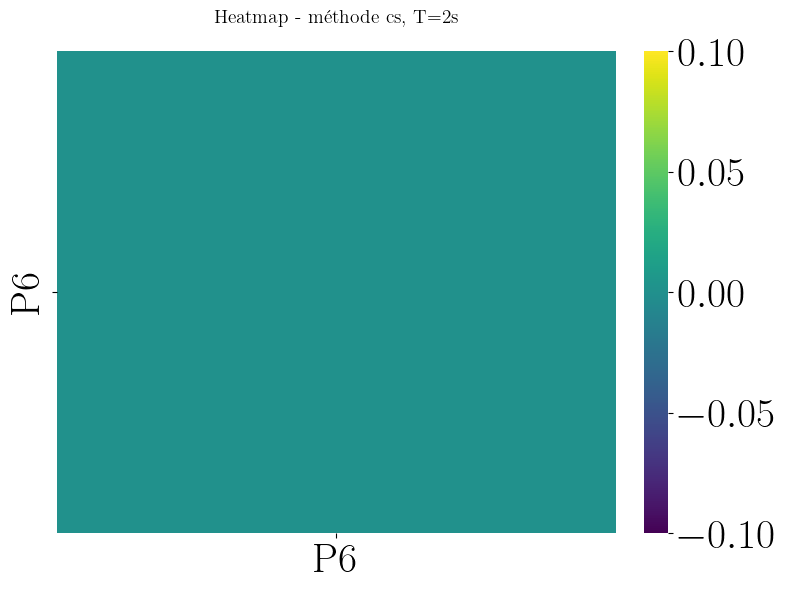

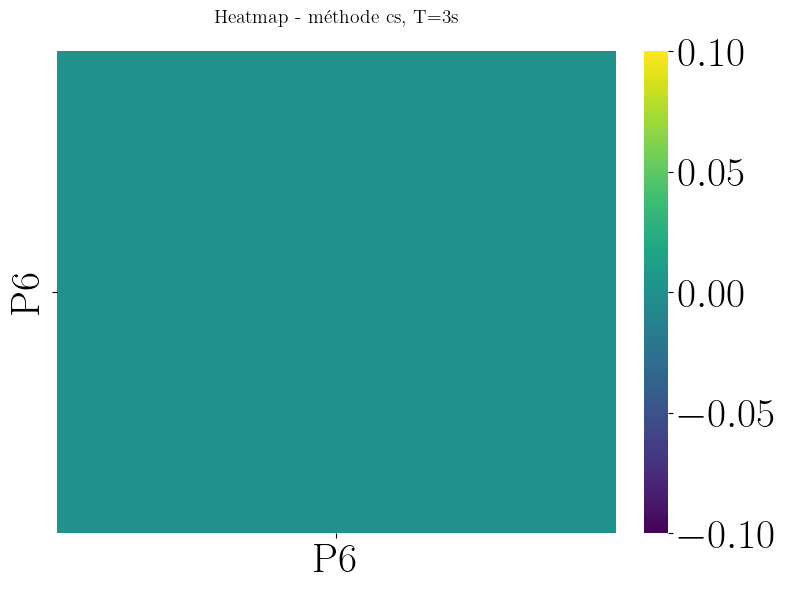

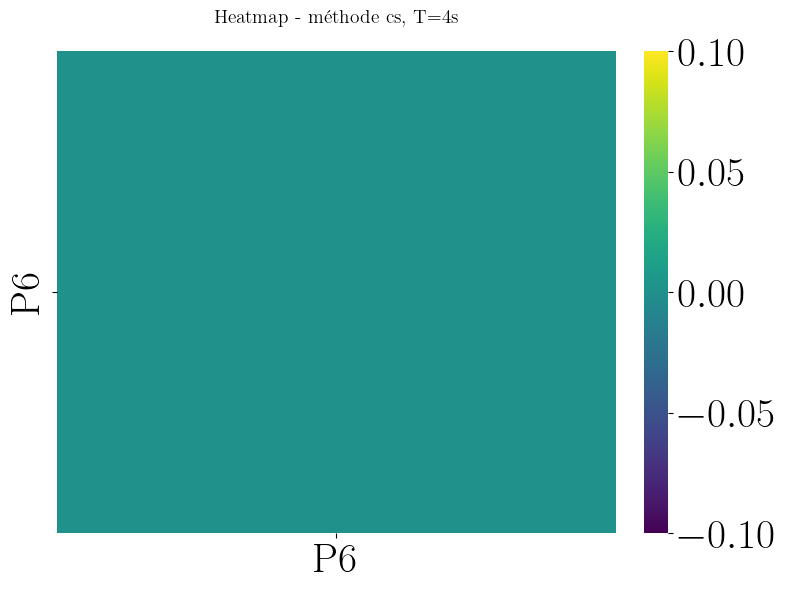

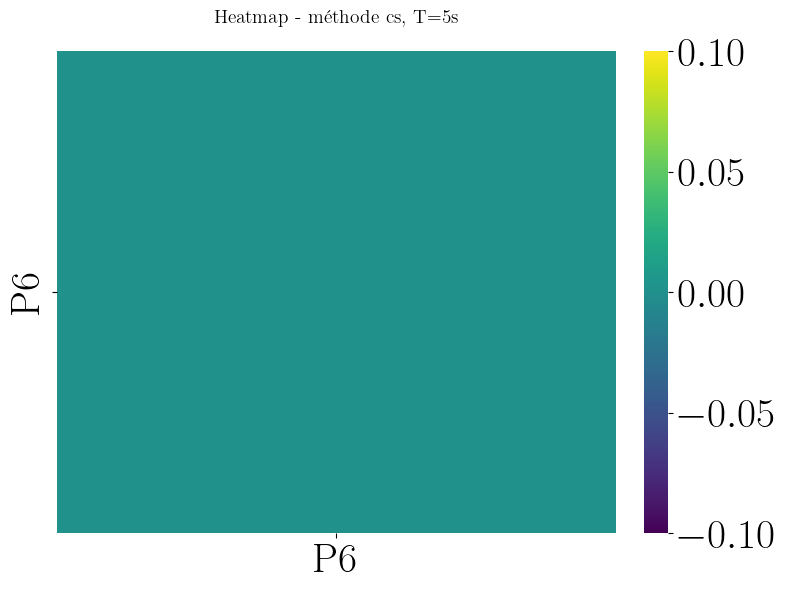

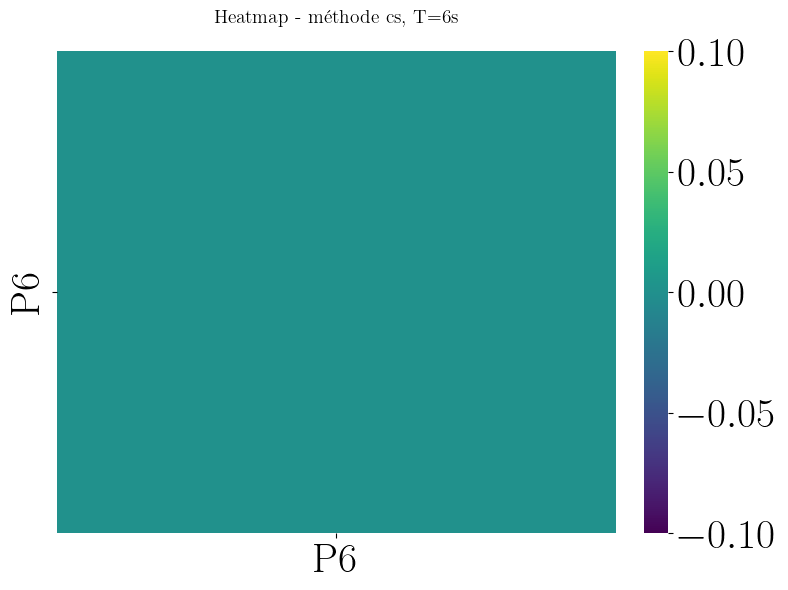

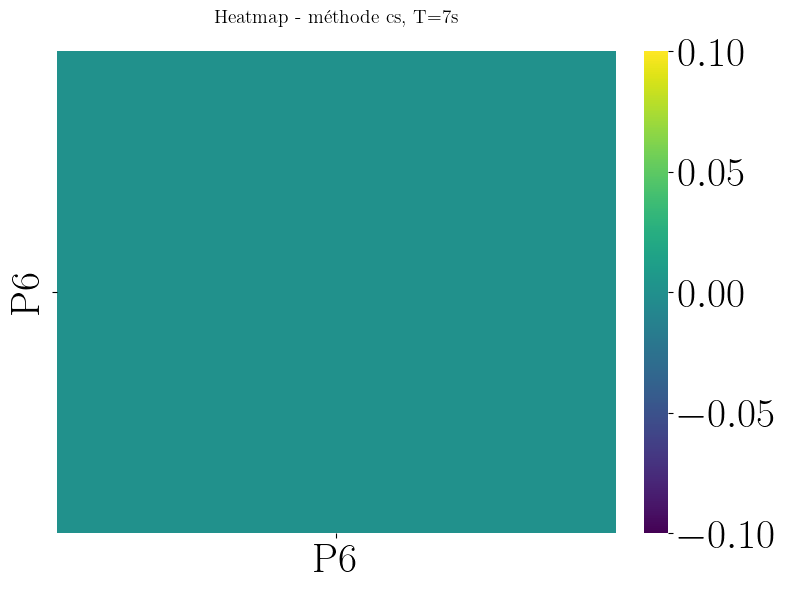

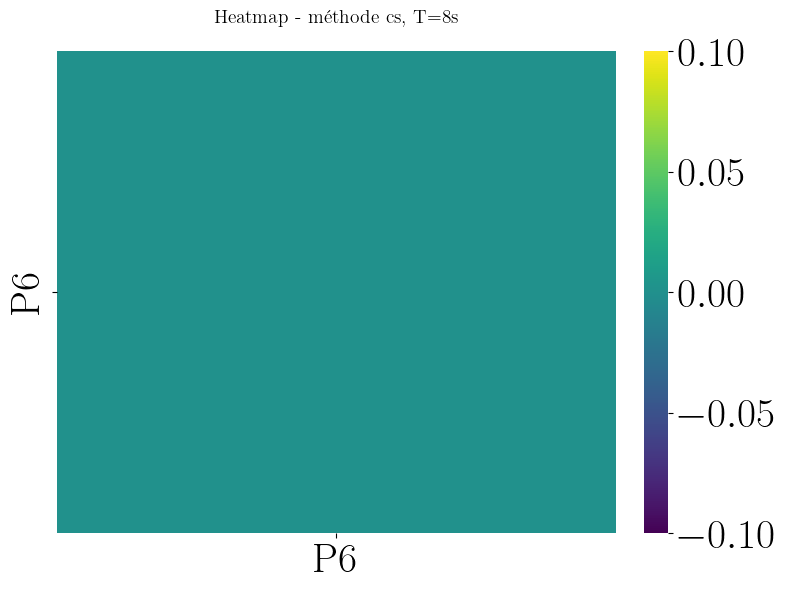

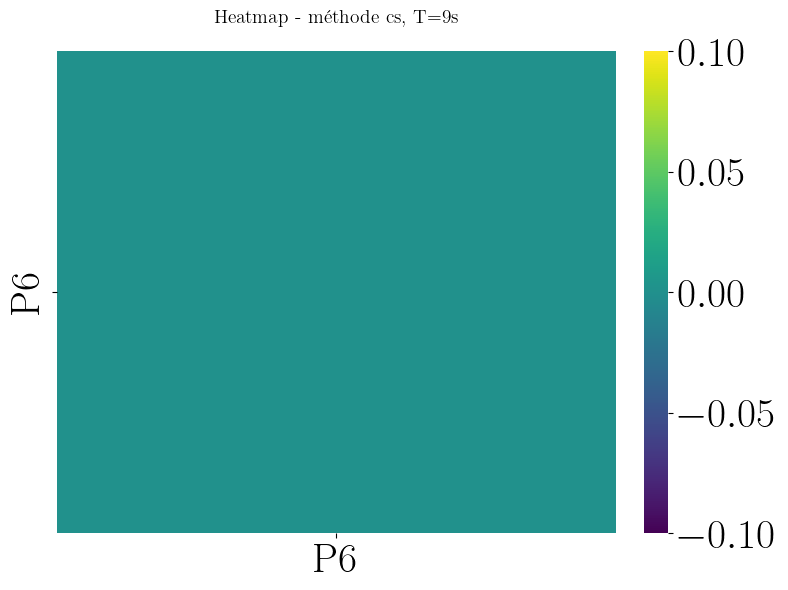

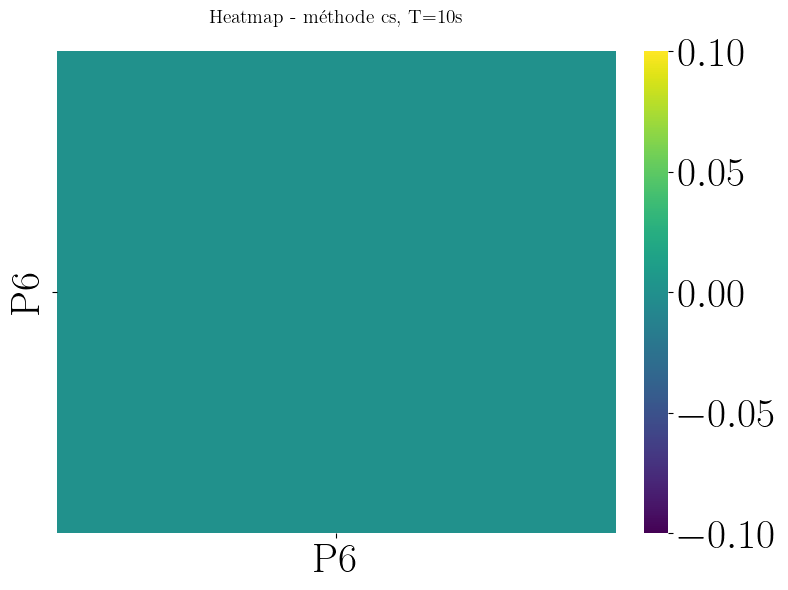

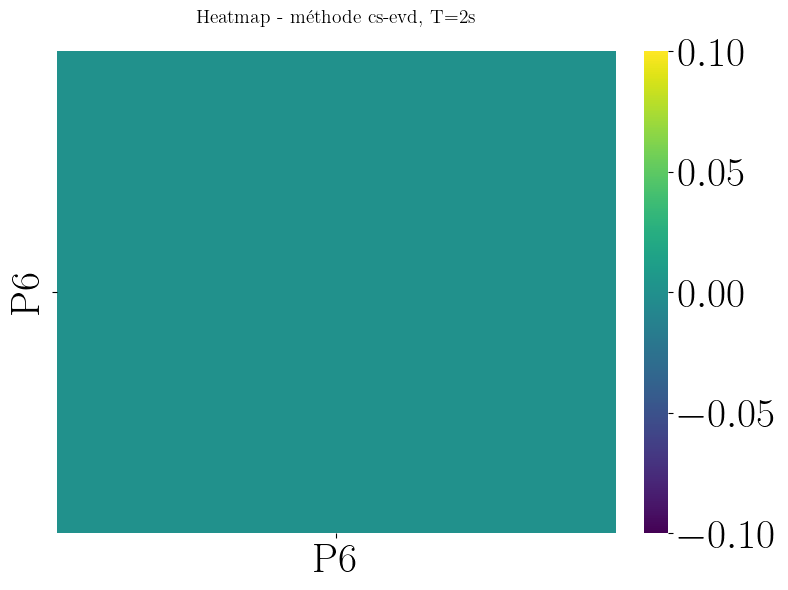

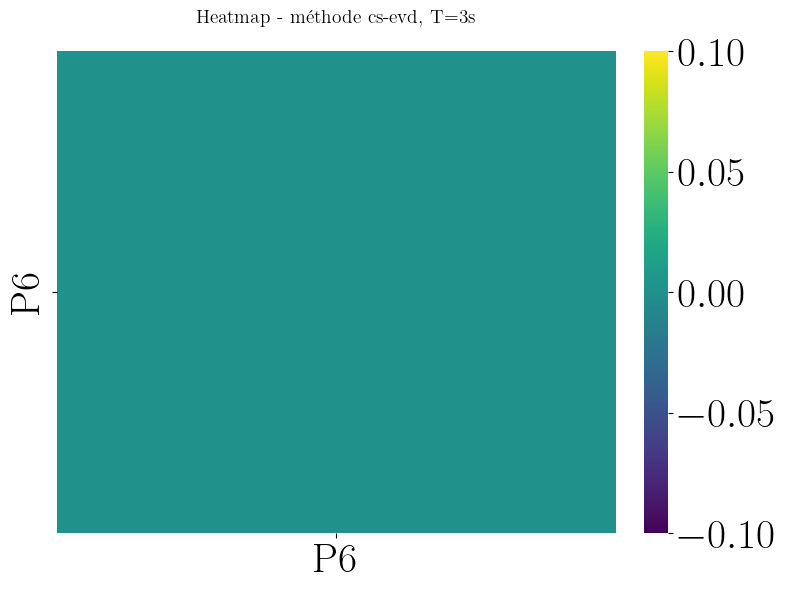

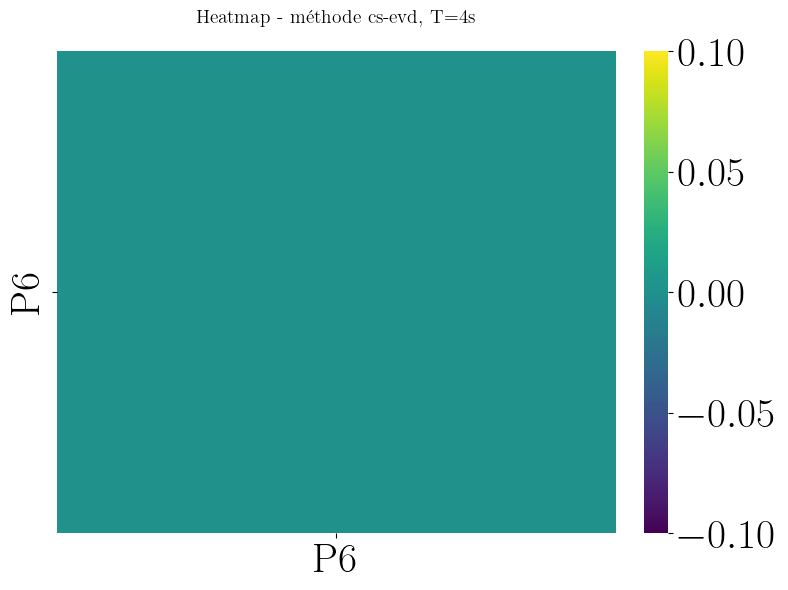

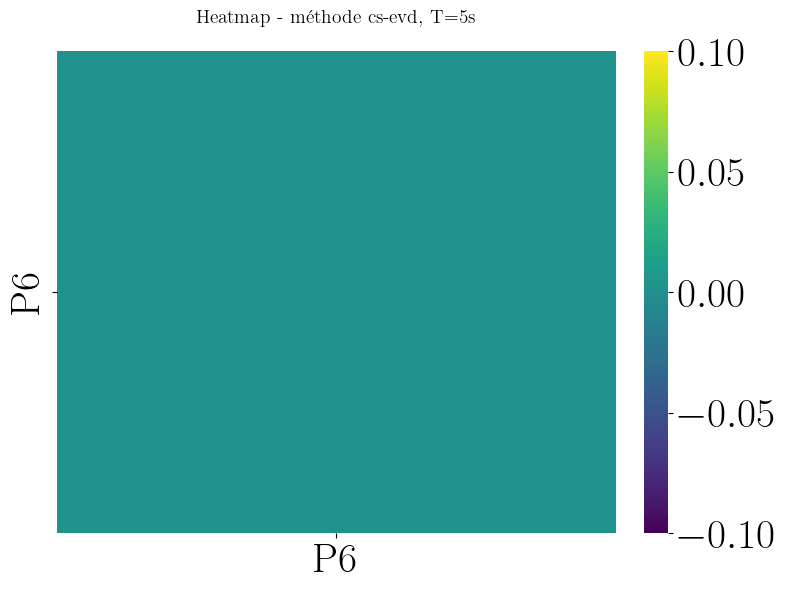

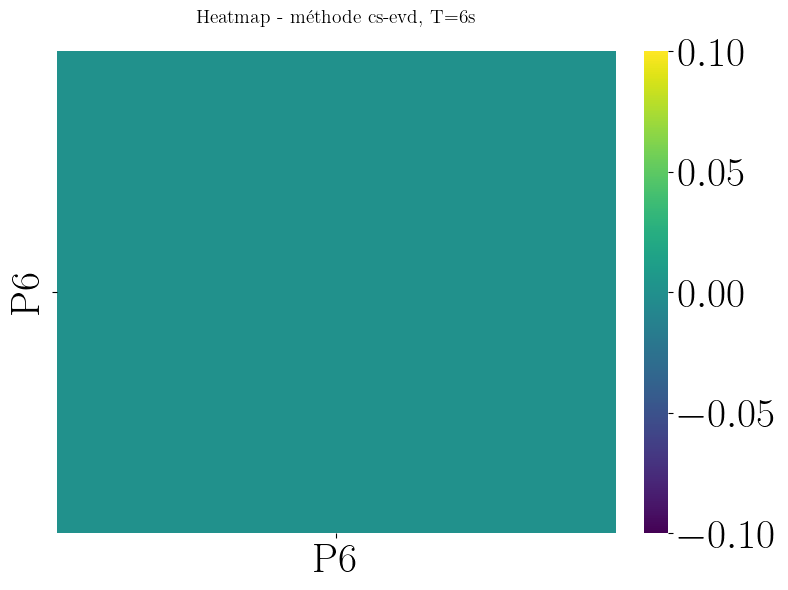

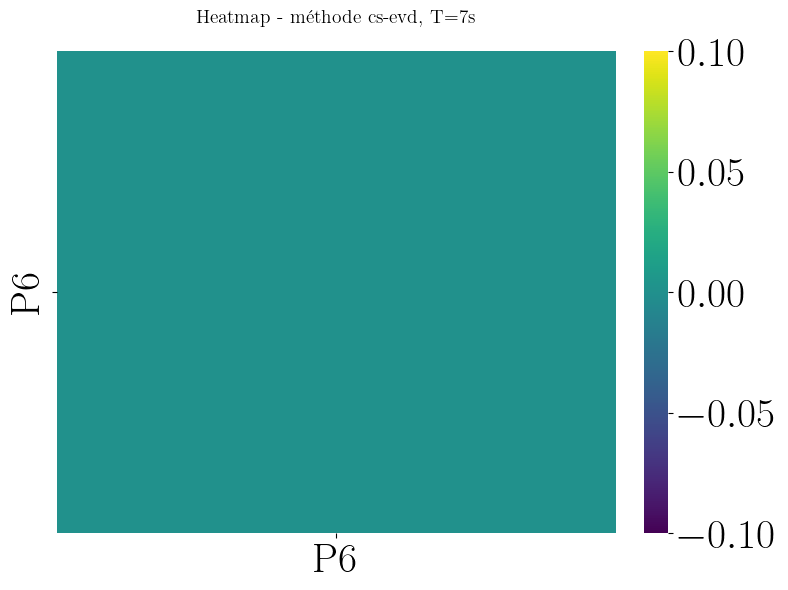

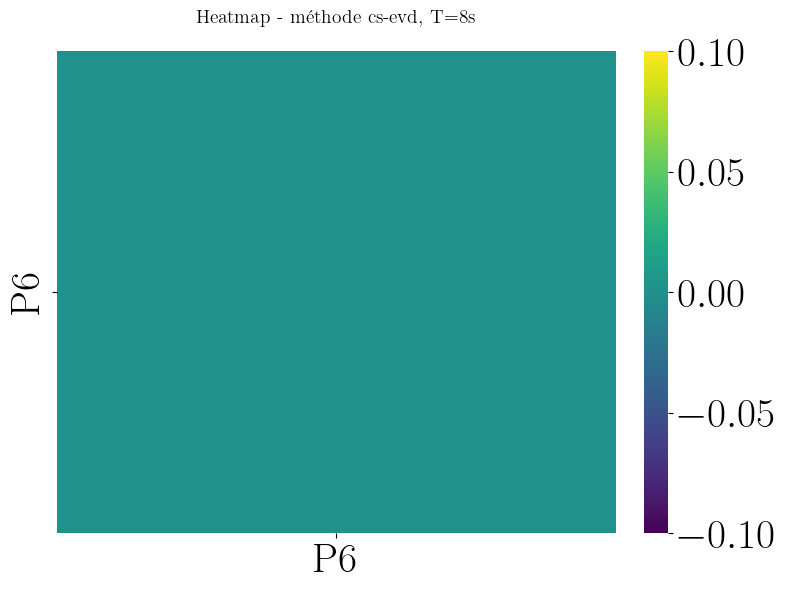

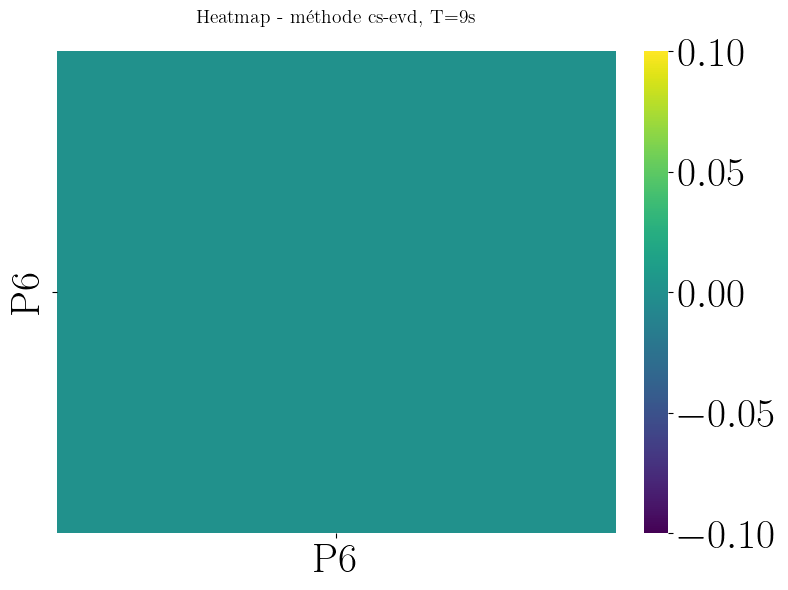

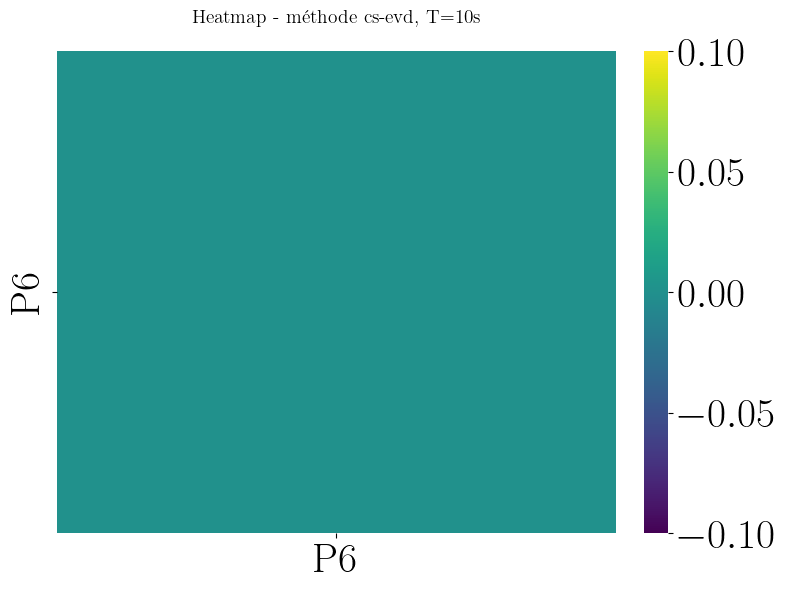

In [ ]:
methods = df["method"].unique()
window_values = df["window_tf"].unique()  # toutes les durées

for method in methods:
    df_method = df[df["method"] == method]

    for win in sorted(window_values):
        # Filtrer pour la durée window_tf spécifique
        df_win = df_method[df_method["window_tf"] == win]

        # Créer un dictionnaire clé=position, valeur=tableau des valeurs
        dist_dict = {
            pos: group["value"].values for pos, group in df_win.groupby("position")
        }
        positions = list(dist_dict.keys())
        n = len(positions)

        # Matrice de distances
        # dist_matrix = np.zeros((n, n))
        # for i, p1 in enumerate(positions):
        #     for j, p2 in enumerate(positions):
        #         if i <= j:
        #             d = wasserstein_distance(dist_dict[p1], dist_dict[p2])
        #             dist_matrix[i, j] = d
        #             dist_matrix[j, i] = d

        ks_matrix = np.zeros((n, n))
        for i, p1 in enumerate(positions):
            for j, p2 in enumerate(positions):
                ks_matrix[i, j] = stats.ks_2samp(dist_dict[p1], dist_dict[p2]).statistic
        dist_matrix = ks_matrix

        # Labels
        labels = [f"{pos}" for pos in positions]

        # Heatmap
        plt.figure(figsize=(8, 6))
        ax = sns.heatmap(
            dist_matrix,
            xticklabels=labels,
            yticklabels=labels,
            cmap="viridis",
            # annot=True,
            # fmt=".2f",
        )
        # ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
        # ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
        plt.title(f"Heatmap - méthode {method}, T={win}s", fontsize=14)
        # plt.tight_layout()
        plt.show()

## Étude de l'angle hermitien moyen en fonction de la bande de fréquence 

On calcule l'angle hermitien à chaque fréquence et on étudie les variations de l'angle moyen en fonction de la bande de fréquence sélectionnée. 

In [ ]:
ax_f = 1
ax_rcv = 0
dist_kwargs_allf = {
    "ax_f": ax_f,
    "unit": "deg",
    "ax_rcv": ax_rcv,
    "apply_mean": False,
    "apply_median": False,
}

# Compute theta for each slice and each freq
fmin = fs_sweep.fmin
fmax = fs_sweep.fmax
# fmin = 10000
# fmax = 13000

init = True
thetas = {rtf_e: {rec: [] for rec in static_records} for rtf_e in rtf_estimators}

for rtf_e in rtf_estimators:

    # Iterate over recordings
    for recording_name in static_records:
        # Iterate over slices
        # theta_slice = []

        for i_slice in range(n_win):
            ds_rtf = results[rtf_e][recording_name][i_slice]
            # nl = ds_rtf.sizes["h_index"]

            # Select frequency band
            ds_rtf = ds_rtf.sel(f_ir=slice(fmin, fmax))
            ds_rtf = ds_rtf.sel(f_rtf=slice(fmin, fmax))

            # Extract RTF ref (from deconvolution)
            rtf_ref_mod = ds_rtf.rtf_amp
            rtf_ref_phase = ds_rtf.rtf_phase
            # Extract RTF hat (from CS-EVD)
            rtf_hat_mod = ds_rtf.rtf_amp_hat
            rtf_hat_phase = ds_rtf.rtf_phase_hat

            # Interp RTF ref at RTF hat frequencies (nearest neigbor)
            rtf_ref_mod = rtf_ref_mod.sel(
                f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
            )
            rtf_ref_phase = rtf_ref_phase.sel(
                f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
            )

            # Build rtfs
            rtf_ref = rtf_ref_mod * np.exp(1j * rtf_ref_phase)
            rtf_hat = rtf_hat_mod * np.exp(1j * rtf_hat_phase)

            # Compute mean theta distance over the frequency band of interest
            theta = dist_func(
                rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs_allf
            )
            thetas[rtf_e][recording_name].append(theta)

            if init:
                thetas["f"] = rtf_hat_mod.f_rtf.values
                init = False

### Angle hermitien pour des bandes de fréquences contigues 

In [ ]:
fmin = fs_sweep.fmin
fmax = fs_sweep.fmax
bandwidth = 1000  # Hz
frequency_bands = [
    (fmin + i * bandwidth, fmin + (i + 1) * bandwidth)
    for i in range(int((fmax - fmin) // bandwidth))
]
center_frequencies = [0.5 * (fb[0] + fb[1]) for fb in frequency_bands]

# Select time window to use -> here we select the maximum duration
time_window_idx = -1  # Last index corresponds to the maximum duration
fig, axs = plt.subplots(3, 2, sharex=True)
fig.suptitle(f"Angle theta par bande de fréquence")

for j, recording_name in enumerate(static_records):
    ax = axs[j // 2, j % 2]
    pos_id = recording_name.split("_")[1]
    for i, rtf_e in enumerate(rtf_estimators):
        theta_band = []
        for fband in frequency_bands:
            fmin_band, fmax_band = fband

            # Select freq indices
            freq_indices = np.where(
                (thetas["f"] >= fmin_band) & (thetas["f"] < fmax_band)
            )[0]

            # Extract theta values for the selected time window and frequency band
            theta_vals = thetas[rtf_e][recording_name][time_window_idx][
                freq_indices
            ]
            # Compute mean theta for the band
            theta_band.append(np.mean(theta_vals))

        ax.plot(
            center_frequencies,
            theta_band,
            label=rtf_e.upper(),
            color=color(i),
        )

    ax.set_title(f"{pos_id} ({dict_th_pos[pos_id]} m)")
    if j == 0:
        ax.legend(fontsize=16, loc="upper right", ncols=2)

In [ ]:
for recording_name in static_records[0:2]:
    # fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
    fig, axs = plt.subplots(1, 1, sharex=True, sharey=True)
    axs = np.atleast_2d(axs)
    fig.suptitle(recording_name)
    # for iwin in range(n_win):
    for iwin in range(1):

        ax = axs[iwin // 3, iwin % 3]
        ax.set_title(f"[0, {Tw[iwin]}]")

        # ax.hist(thetas["cs"][recording_name][iwin], bins=200, density=True, color=color(0), label="cs")
        # ax.hist(
        #     thetas["cs-evd"][recording_name][iwin],
        #     bins=200,
        #     density=True,
        #     color=color(1),
        #     label="cs-evd",
        # )


        df_theta = pd.DataFrame.from_dict(
            {
                "cs": thetas["cs"][recording_name][iwin],
                "cs-evd": thetas["cs-evd"][recording_name][iwin],
            }
        )
        sns.displot(thetas["cs"][recording_name][iwin], kind="kde", fill=True)

        # Derive quartile
        q1_cs, q2_cs, q3_cs = np.quantile(a=thetas["cs"][recording_name][iwin], q=[0.25, 0.5, 0.75])
        q1_cs_evd, q2_cs_evd, q3_cs_evd = np.quantile(a=thetas["cs-evd"][recording_name][iwin], q=[0.25, 0.5, 0.75])

        # Add annotations
        # CS
        for iq, q in enumerate([q1_cs, q2_cs, q3_cs]):
            ax.annotate(
                f"Q{iq+1}",
                xy=(q, ax.get_ylim()[0]),
                xytext=(q, ax.get_ylim()[0] - ax.get_ylim()[1] * 0.1),
                color=color(0),
                arrowprops=dict(facecolor=color(0), lw=2, width=2),
                ha="center",
                size=16,
            )

        # CS-EVD
        for iq, q in enumerate([q1_cs_evd, q2_cs_evd, q3_cs_evd]):
            ax.annotate(
                f"Q{iq+1}",
                xy=(q, ax.get_ylim()[1]),
                xytext=(q, ax.get_ylim()[1]*1.1),
                color=color(1),
                arrowprops=dict(facecolor=color(1), lw=2, width=2),
                ha="center",
                size=16,
            )

        # ax.axvline(np.mean(thetas["cs-evd"][recording_name][iwin]), color=color(1), label=r"$\mu_{cs-evd}$")
        # ax.axvline(
        #     np.median(thetas["cs"][recording_name][iwin]), linestyle="--", color=color(1), label="median(cs-evd)"
        # )

        ax.legend()

# print("cs", np.max(thetas["cs"][recording_name][0]))
# print("cs-evd", np.max(thetas["cs-evd"][recording_name][0]))

In [ ]:
import seaborn as sns 

In [ ]:
# df_theta = thetas["cs"][recording_name][iwin]
sns.displot(thetas["cs"][recording_name][iwin], kind="kde", fill=True)

### LEFT OVERS

In [ ]:
import seaborn as sns 

In [ ]:
# df_theta = thetas["cs"][recording_name][iwin]
sns.displot(thetas["cs"][recording_name][iwin], kind="kde", fill=True)